In [2]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [3]:
import pandas as pd
import spacy
import re
from itertools import chain
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import gensim
import gensim.corpora as corpora

In [4]:
plt.rcParams['figure.figsize'] = (12,8)
default_plot_color = "#00bfbf"

In [5]:
data = pd.read_csv('imdb_movie_reviews.csv')[0:500]

In [6]:
data.head()

,text,sentiment
0,"My daughter liked it but I was aghast, that a ...",neg
1,I... No words. No words can describe this. I w...,neg
2,this film is basically a poor take on the old ...,neg
3,"This is a terrible movie, and I'm not even sur...",neg
4,First of all this movie is a piece of reality ...,pos


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       500 non-null    object
 1   sentiment  500 non-null    object
dtypes: object(2)
memory usage: 7.9+ KB


Text(0, 0.5, 'counts')

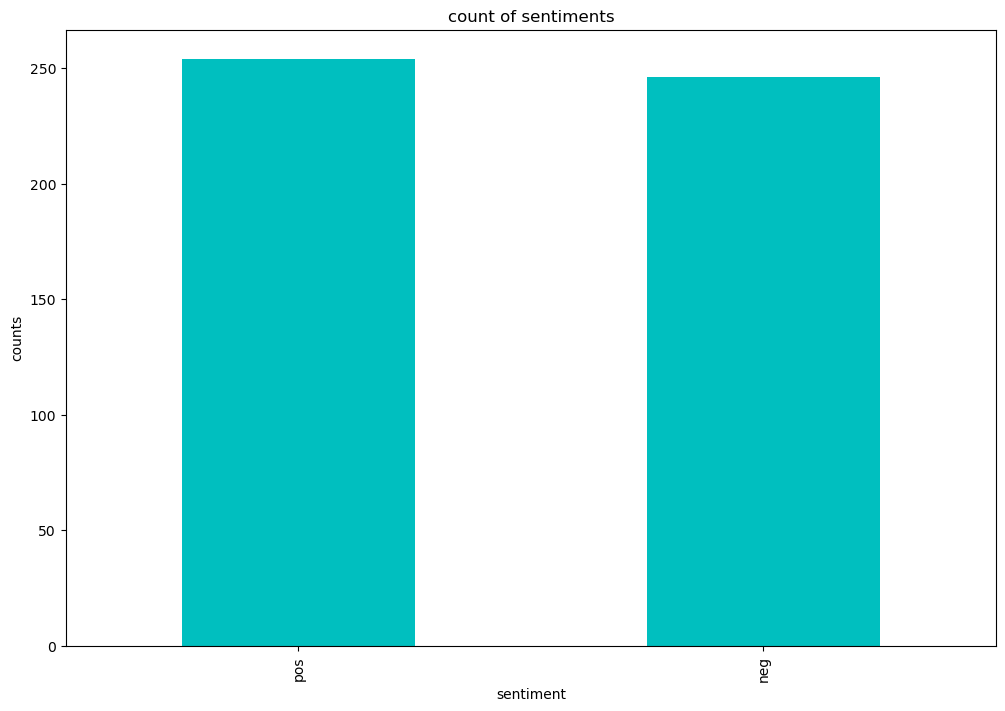

In [8]:
data['sentiment'].value_counts().plot(kind= 'bar', color = default_plot_color)
plt.title('count of sentiments')
plt.xlabel('sentiment')
plt.ylabel('counts')

In [9]:
data_neg = data[data['sentiment'] == 'neg']
data_neg.head()

,text,sentiment
0,"My daughter liked it but I was aghast, that a ...",neg
1,I... No words. No words can describe this. I w...,neg
2,this film is basically a poor take on the old ...,neg
3,"This is a terrible movie, and I'm not even sur...",neg
5,"As a young lass, beautiful Joan Woodbury (as R...",neg


In [10]:
data_positive =  data[data['sentiment'] == 'pos']
data_positive.head()

,text,sentiment
4,First of all this movie is a piece of reality ...,pos
8,If you want to see a film starring Stan laurel...,pos
11,Cocky medical students play chicken with proce...,pos
12,This movie is excellent in how it portrays the...,pos
14,So after years and years I finally track this ...,pos


In [11]:
nlp = spacy.load('en_core_web_sm')

In [12]:
neg_nlp_doc = list(nlp.pipe(data_neg['text']))
print(neg_nlp_doc)

[My daughter liked it but I was aghast, that a character in this movie smokes. As if it isn't awful enough to see "product placement" actors like Bruce Willis who smoke in their movies - at least children movies should be more considerate! I wonder: was that intentional? Did big tobacco "sponsor" the film? What does it take to ban smoking from films? At least films intended for children and adolescents. My daughter liked it but I was aghast, that a character in this movie smokes. As if it isn't awful enough to see "product placement" actors like Bruce Willis who smoke in their movies - at least children movies should be more considerate! I wonder: was that intentional? Did big tobacco "sponsor" the film? What does it take to ban smoking from films? At least films intended for children and adolescents., I... No words. No words can describe this. I will try for the sake of those few brave people who stick knives into their toasters... after watching this show.<br /><br />This... Cosgrove

In [13]:
pos_nlp_doc = list(nlp.pipe(data_positive['text']))
print(pos_nlp_doc)

[First of all this movie is a piece of reality very well realized artistically. Some kind of combination between "American Beauty" and "As Good as it gets". And of course something specifically to all Russian movies ( of course the valuable one, no dirty propaganda !) : the problem of loneliness of man ... Especially recommended for the people which really want to see beyond all vomitive propaganda about communism ( both positive or negative propaganda ! ). A movie about common people, their problems, lack of satisfactions - especially for young ones, fear when touch the real and too dirty face of the society ... and about the fake "solutions" : alcohol and violence ... and probably the only real solution : true love ... Of course it's very well "located" in the space and time of "Russian perestroika" but it's valid for all the society ( except a perfect one, but don't worry - not possible to find this on our Earth !). For the last time - definitely recommended ..., If you want to see 

In [14]:
def extract_token(doc):
    return [(token.text, token.ent_type_, token.pos_) for token in doc]

In [15]:
neg_tagsdf = []
pos_tagsdf = []
columns = ['token', 'ner', 'pos']

for doc in neg_nlp_doc:
    neg_tagsdf.extend(extract_token(doc)) 

for doc in pos_nlp_doc:
    pos_tagsdf.extend(extract_token(doc)) 


neg_table = pd.DataFrame(neg_tagsdf, columns= columns)
pos_table = pd.DataFrame(pos_tagsdf, columns= columns)
pos_table.head(100)

,token,ner,pos
0,First,ORDINAL,ADV
1,of,,ADP
2,all,,DET
3,this,,DET
4,movie,,NOUN
...,...,...,...
95,",",,PUNCT
96,lack,,NOUN
97,of,,ADP
98,satisfactions,,NOUN


In [16]:
positive_pos_table = pos_table.groupby(['token','pos']).size().reset_index(name= 'count').sort_values(by= 'count', ascending= False)
positive_pos_table.head()

,token,pos,count
9965,the,DET,2993
40,",",PUNCT,2773
53,.,PUNCT,2262
3763,and,CCONJ,1659
3526,a,DET,1487


In [17]:
negative_pos_table = neg_table.groupby(['token', 'pos']).size().reset_index(name= 'count').sort_values(by= 'count', ascending= False)
negative_pos_table.head()

,token,pos,count
8873,the,DET,2473
35,",",PUNCT,2121
48,.,PUNCT,2102
2865,a,DET,1356
6908,of,ADP,1217


In [18]:
positive_pos_count = positive_pos_table.groupby('pos')['token'].count().sort_values(ascending= False)
positive_pos_count.head()

pos
NOUN     3408
PROPN    2599
VERB     1991
ADJ      1440
ADV       563
Name: token, dtype: int64

In [19]:
negative_pos_count = negative_pos_table.groupby('pos')['token'].count().sort_values(ascending= False)
negative_pos_count.head()

pos
NOUN     3166
PROPN    2000
VERB     1887
ADJ      1318
ADV       538
Name: token, dtype: int64

In [20]:
positive_noun_table = positive_pos_table[positive_pos_table.pos == 'NOUN']
positive_noun_table.head()

,token,pos,count
5946,film,NOUN,406
7615,movie,NOUN,405
9612,story,NOUN,142
10071,time,NOUN,109
4473,characters,NOUN,80


In [21]:
negative_noun_table = negative_pos_table[negative_pos_table.pos == 'NOUN']
negative_noun_table.head()

,token,pos,count
6679,movie,NOUN,442
5134,film,NOUN,366
8959,time,NOUN,97
7253,plot,NOUN,67
3796,characters,NOUN,65


In [22]:
positive_ner_table = pos_table[pos_table.ner != '']
positive_ner_table = positive_ner_table.groupby(['token', 'ner']).size().reset_index(name='count').sort_values(by='count', ascending= False)
positive_ner_table.head(10)

,token,ner,count
2680,one,CARDINAL,82
2590,first,ORDINAL,71
2775,years,DATE,69
2755,two,CARDINAL,58
2276,The,WORK_OF_ART,56
2725,the,DATE,54
20,'s,PERSON,49
2745,three,CARDINAL,40
292,American,NORP,32
2731,the,ORG,30


In [23]:
negative_ner_table = neg_table[neg_table.ner != '']
negative_ner_table = negative_ner_table.groupby(['token', 'ner']).size().reset_index(name='count').sort_values(by='count', ascending= False)
negative_ner_table.head()

,token,ner,count
2065,one,CARDINAL,84
1984,first,ORDINAL,52
2146,two,CARDINAL,51
20,'s,PERSON,41
2118,the,DATE,33


In [24]:
ner_tags = ['CARDINAL', 'ORDINAL', 'DATE', 'WORK_OF_ART', 'PERSON', 'NORP', 'ORG']

ner_color = sns.color_palette(palette= 'hls', n_colors= len(ner_tags)).as_hex()
ner_palette = dict(zip(ner_tags, ner_color))

[Text(0.5, 1.0, 'Most common ner in positive comments')]

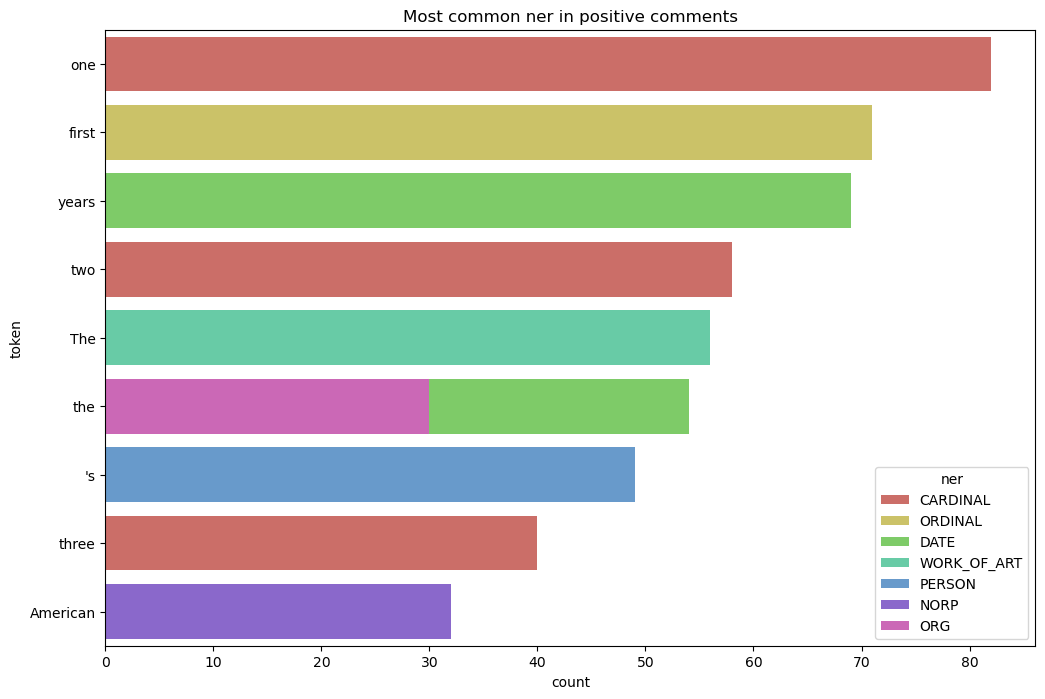

In [25]:
sns.barplot(
    data= positive_ner_table[0:10],
    x= 'count',
    y= 'token',
    orient= 'h',
    hue= 'ner',
    dodge= False,
    palette= ner_palette
).set(title = 'Most common ner in positive comments')

In [26]:
data.head()

,text,sentiment
0,"My daughter liked it but I was aghast, that a ...",neg
1,I... No words. No words can describe this. I w...,neg
2,this film is basically a poor take on the old ...,neg
3,"This is a terrible movie, and I'm not even sur...",neg
4,First of all this movie is a piece of reality ...,pos


In [27]:
data['text-clean'] = data['text'].apply(lambda x:  re.sub(r'[^\w\s]', '',x)).str.lower()
data.head()

,text,sentiment,text-clean
0,"My daughter liked it but I was aghast, that a ...",neg,my daughter liked it but i was aghast that a c...
1,I... No words. No words can describe this. I w...,neg,i no words no words can describe this i will t...
2,this film is basically a poor take on the old ...,neg,this film is basically a poor take on the old ...
3,"This is a terrible movie, and I'm not even sur...",neg,this is a terrible movie and im not even sure ...
4,First of all this movie is a piece of reality ...,pos,first of all this movie is a piece of reality ...


In [28]:
nltk.download('stopwords')
en_stopwords = stopwords.words('english')
en_stopwords.append('br')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\usama\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [29]:
data['text-clean'] = data['text-clean'].apply(lambda x: ' '.join(words for words in x.split() if words not in en_stopwords))
data.head()

,text,sentiment,text-clean
0,"My daughter liked it but I was aghast, that a ...",neg,daughter liked aghast character movie smokes i...
1,I... No words. No words can describe this. I w...,neg,words words describe try sake brave people sti...
2,this film is basically a poor take on the old ...,neg,film basically poor take old urban legend baby...
3,"This is a terrible movie, and I'm not even sur...",neg,terrible movie im even sure terrible ugly one ...
4,First of all this movie is a piece of reality ...,pos,first movie piece reality well realized artist...


In [30]:
data['text-clean'] = data['text-clean'].apply(lambda x : word_tokenize(x))
data.head()

,text,sentiment,text-clean
0,"My daughter liked it but I was aghast, that a ...",neg,"[daughter, liked, aghast, character, movie, sm..."
1,I... No words. No words can describe this. I w...,neg,"[words, words, describe, try, sake, brave, peo..."
2,this film is basically a poor take on the old ...,neg,"[film, basically, poor, take, old, urban, lege..."
3,"This is a terrible movie, and I'm not even sur...",neg,"[terrible, movie, im, even, sure, terrible, ug..."
4,First of all this movie is a piece of reality ...,pos,"[first, movie, piece, reality, well, realized,..."


In [31]:
lemmatizer = WordNetLemmatizer()
data['text-clean'] = data['text-clean'].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])
data.head()

# word for word in x jesa kuch use kro to wo method ke andr use hga to [] ki need nhi hgi warna 
# () se bahr ho to [] lgane parenge eg.  .join(words for words in x.split() if words not in en_stopwords))
# theek hai mgr lambda x: [lemmatizer.lemmatize(word) for word in x] kiunke () me nhi is lye 
# [ ] ayengay 

,text,sentiment,text-clean
0,"My daughter liked it but I was aghast, that a ...",neg,"[daughter, liked, aghast, character, movie, sm..."
1,I... No words. No words can describe this. I w...,neg,"[word, word, describe, try, sake, brave, peopl..."
2,this film is basically a poor take on the old ...,neg,"[film, basically, poor, take, old, urban, lege..."
3,"This is a terrible movie, and I'm not even sur...",neg,"[terrible, movie, im, even, sure, terrible, ug..."
4,First of all this movie is a piece of reality ...,pos,"[first, movie, piece, reality, well, realized,..."


In [32]:
token_clean = list(chain.from_iterable(data['text-clean']))

In [33]:
unigrams = (pd.Series(nltk.ngrams(token_clean, 1))).value_counts().reset_index()
unigrams.head()

,index,count
0,"(movie,)",979
1,"(film,)",923
2,"(one,)",511
3,"(like,)",401
4,"(good,)",269


In [34]:
unigrams['index'] = unigrams['index'].apply(lambda x: x[0])
unigrams.head()

,index,count
0,movie,979
1,film,923
2,one,511
3,like,401
4,good,269


<Axes: xlabel='count', ylabel='index'>

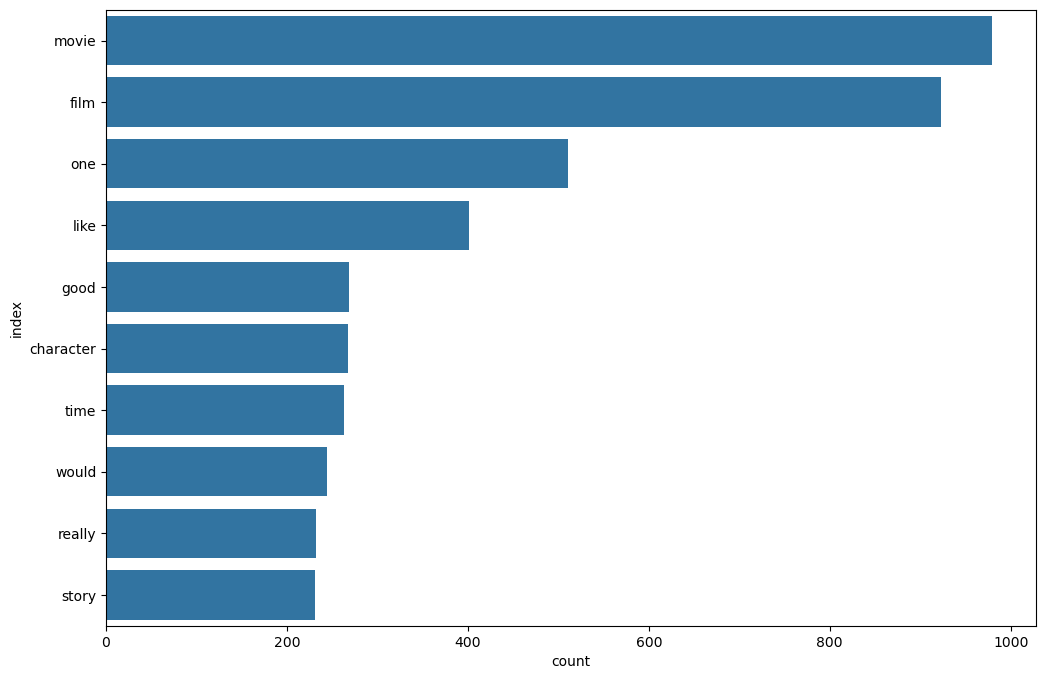

In [35]:
sns.barplot(
    data= unigrams[0:10],
    x= 'count',
    y= 'index',
    orient= 'h',
)

value_counts()

Called on a Series (or a single column).
Counts occurrences of each unique value.
Automatically sorts by count, descending, by default.
Drops NaN by default (dropna=True).


size()

Usually called after a groupby() — works on groups, not raw values.
Returns the number of rows in each group (including NaNs, unlike value_counts()).
Does NOT sort by count — keeps groups in their natural/grouped order.

In [36]:
bigrams = pd.Series(nltk.ngrams(token_clean, 2)).value_counts().reset_index()
bigrams

,index,count
0,"(ever, seen)",29
1,"(look, like)",28
2,"(horror, film)",24
3,"(can, not)",21
4,"(ive, seen)",20
...,...,...
51392,"(good, direction)",1
51393,"(beautiful, good)",1
51394,"(look, beautiful)",1
51395,"(longer, scene)",1


In [37]:
bigrams['index'] = bigrams['index'].apply(lambda x: ' '.join(x))
bigrams

,index,count
0,ever seen,29
1,look like,28
2,horror film,24
3,can not,21
4,ive seen,20
...,...,...
51392,good direction,1
51393,beautiful good,1
51394,look beautiful,1
51395,longer scene,1


[Text(0.5, 1.0, 'Most common bigrams')]

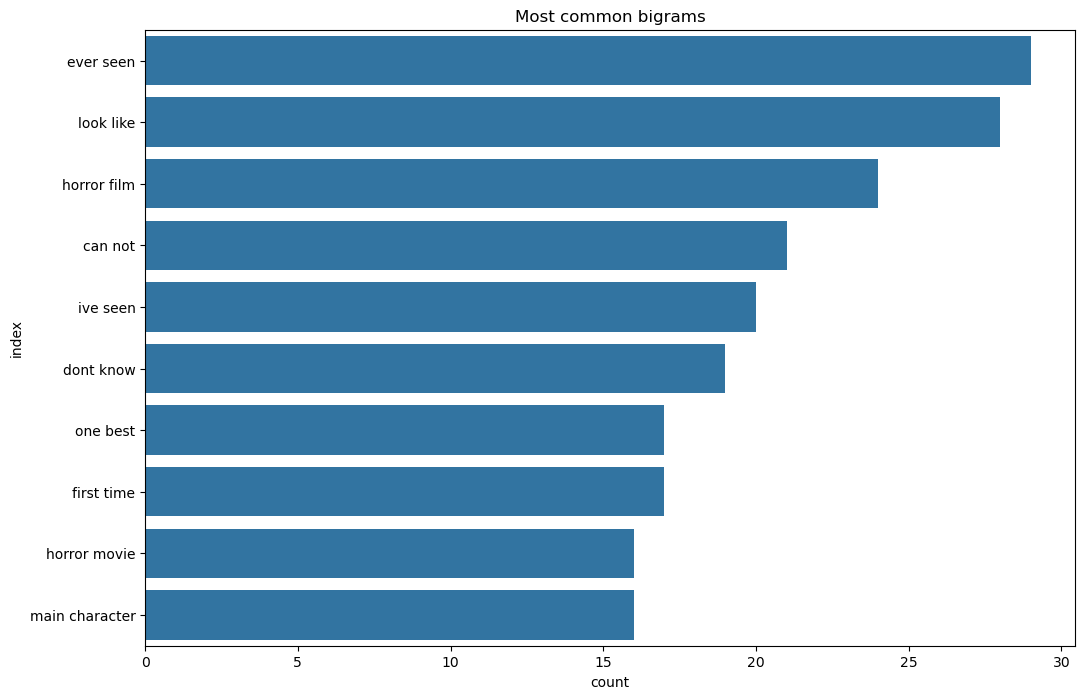

In [38]:
sns.barplot(
    data= bigrams[0:10],
    x= 'count',
    y = 'index',
    orient= 'h'
).set(title = 'Most common bigrams')

In [39]:
data.head()

,text,sentiment,text-clean
0,"My daughter liked it but I was aghast, that a ...",neg,"[daughter, liked, aghast, character, movie, sm..."
1,I... No words. No words can describe this. I w...,neg,"[word, word, describe, try, sake, brave, peopl..."
2,this film is basically a poor take on the old ...,neg,"[film, basically, poor, take, old, urban, lege..."
3,"This is a terrible movie, and I'm not even sur...",neg,"[terrible, movie, im, even, sure, terrible, ug..."
4,First of all this movie is a piece of reality ...,pos,"[first, movie, piece, reality, well, realized,..."


In [40]:
dictionary = corpora.Dictionary(data['text-clean'])
print(dictionary)

Dictionary<12193 unique tokens: ['actor', 'adolescent', 'aghast', 'awful', 'ban']...>


In [41]:
docterm = [dictionary.doc2bow(docs) for docs in data['text-clean']]
print(docterm)

[[(0, 2), (1, 2), (2, 2), (3, 2), (4, 2), (5, 2), (6, 2), (7, 2), (8, 4), (9, 2), (10, 2), (11, 2), (12, 6), (13, 2), (14, 2), (15, 2), (16, 4), (17, 2), (18, 2), (19, 6), (20, 2), (21, 2), (22, 2), (23, 4), (24, 2), (25, 2), (26, 2), (27, 2), (28, 2), (29, 2)], [(0, 1), (7, 1), (17, 2), (30, 1), (31, 1), (32, 1), (33, 1), (34, 1), (35, 1), (36, 1), (37, 1), (38, 1), (39, 1), (40, 1), (41, 1), (42, 1), (43, 1), (44, 1), (45, 1), (46, 1), (47, 1), (48, 1), (49, 1), (50, 1), (51, 1), (52, 1), (53, 1), (54, 1), (55, 1), (56, 1), (57, 2), (58, 1), (59, 1), (60, 1), (61, 1), (62, 1), (63, 1), (64, 1), (65, 1), (66, 1), (67, 1), (68, 1), (69, 1), (70, 1), (71, 1), (72, 1), (73, 1), (74, 1), (75, 1), (76, 1), (77, 1), (78, 1), (79, 1), (80, 1), (81, 1), (82, 1), (83, 1), (84, 1), (85, 1), (86, 1), (87, 1), (88, 1), (89, 1), (90, 1), (91, 1), (92, 1), (93, 1), (94, 1), (95, 1), (96, 1), (97, 1), (98, 1), (99, 1), (100, 1), (101, 1), (102, 1), (103, 1), (104, 1), (105, 1), (106, 1), (107, 1), (

In [45]:
coherence_values = []
models_list =[]

min_topics = 2
max_topics = 11

for num_topics_i in range(min_topics, max_topics+1):
    lda = gensim.models.LdaModel(corpus= docterm, num_topics= num_topics_i, id2word= dictionary)
    models_list.append(lda)
    coherence_model = gensim.models.CoherenceModel(model = lda , texts= data['text-clean'], dictionary= dictionary, coherence= 'c_v')
    coherence_values.append(coherence_model.get_coherence())


print(coherence_values)




[np.float64(0.29856004913611645), np.float64(0.3042922269136281), np.float64(0.2899146509622579), np.float64(0.28997971598076244), np.float64(0.27921926693099935), np.float64(0.2917073142259662), np.float64(0.29350257230492943), np.float64(0.29195559744893734), np.float64(0.2795235642803263), np.float64(0.29598278348675644)]


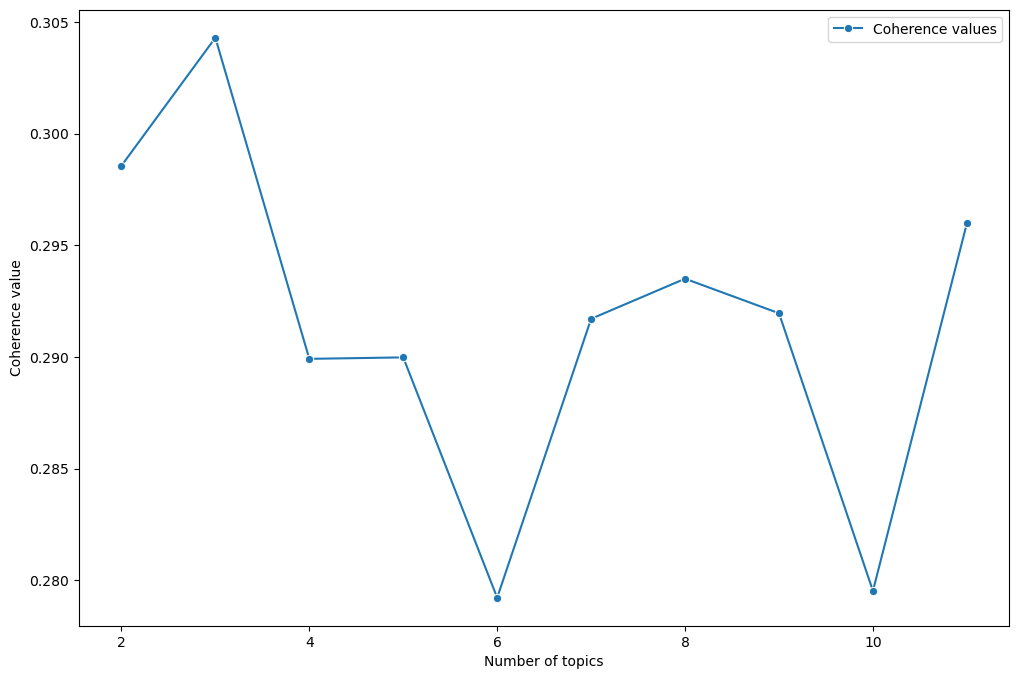

In [50]:
sns.lineplot(
    x= range(min_topics, max_topics+1),
    y = coherence_values,
    label = 'Coherence values',
    marker= 'o'
)
plt.xlabel("Number of topics")
plt.ylabel("Coherence value")
plt.show()


In [51]:
num_topics = 3

In [58]:
lda_model = gensim.models.LdaModel(corpus= docterm, num_topics= num_topics , id2word= dictionary)

lda_model.print_topics(num_topics= num_topics, num_words= 5)




[(0,
  '0.018*"film" + 0.010*"movie" + 0.007*"like" + 0.006*"one" + 0.004*"character"'),
 (1,
  '0.014*"movie" + 0.008*"film" + 0.007*"one" + 0.005*"would" + 0.004*"get"'),
 (2,
  '0.018*"movie" + 0.012*"film" + 0.009*"one" + 0.006*"like" + 0.004*"time"')]

In [59]:
coherence_model =  gensim.models.CoherenceModel(model= lda_model,corpus= docterm,  texts= data['text-clean'], dictionary= dictionary, coherence = 'c_v')
print(coherence_model.get_coherence_per_topic())

[np.float64(0.2806197480468006), np.float64(0.28574474978250863), np.float64(0.3229214271895996)]
